<a href="https://colab.research.google.com/github/Tayli05/INTELIGENCIA-ARTIFICIAL-1/blob/main/Lab2_reg_lin_mul_01.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Ejercicio de programación Regresión Lineal Multiple

In [41]:
# utilizado para manejos de directorios y rutas
import os

# Computacion vectorial y cientifica para python
import numpy as np
import pandas as pd
# Librerias para graficación (trazado de gráficos)
from matplotlib import pyplot
from mpl_toolkits.mplot3d import Axes3D  # Necesario para graficar superficies 3D

# llama a matplotlib a embeber graficas dentro de los cuadernillos
%matplotlib inline

In [42]:
from google.colab import drive
drive.mount("/content/gdrive")

Drive already mounted at /content/gdrive; to attempt to forcibly remount, call drive.mount("/content/gdrive", force_remount=True).


## 2 Regresión lineal con multiples variables

En este laboratorio se aplica la regresión lineal multivariable para predecir el consumo de energía de los electrodomésticos en un hogar (medido en Vatios-hora, Wh).Para este ejercicio utilizamos el conjunto de datos energydata_complete.csv. La primera columna corresponde a la fecha de registro, la segunda columna es nuestra variable objetivo Appliances (consumo eléctrico que se desea predecir), y las siguientes 27 columnas son las características explicativas ($X$). Entre estas características se encuentran el nivel de iluminación (lights), diversas mediciones de temperatura interna y externa ($T_1$ a $T_9$, $T_{out}$), niveles de humedad relativa ($RH_1$ a $RH_9$, $RH_{out}$), presión atmosférica, velocidad del viento, visibilidad y variables aleatorias de control.

<a id="section4"></a>
### 2.1 Normalización de caracteristicas

Al revisar el dataset se observa que las variables manejan escalas numéricas muy distintas. Por ejemplo, los valores de temperatura varían en rangos pequeños de $15$ a $25\ ^\circ\text{C}$, la presión atmosférica registra valores cercanos a los $730\text{ mmHg}$ y la visibilidad alcanza hasta los $60\text{ km}$.

Cuando las características tienen magnitudes tan diferentes, la función de costo se deforma y al descenso por el gradiente le cuesta mucho más trabajo encontrar el punto óptimo. Por esta razón, aplicamos la normalización de características (restando la media $\mu$ y dividiendo entre la desviación estándar $\sigma$). Esto transforma todas las variables a una escala común (con media $0$ y desviación estándar $1$), lo que permite que el algoritmo de gradiente descendente converja mucho más rápido y de forma estable hacia el menor costo posible.

In [43]:
# Cargar datos
# data = np.loadtxt(os.path.join('Datasets', 'ex1data2.txt'), delimiter=',')
data = '/content/gdrive/MyDrive/InteligenciaArtificial/energydata_complete - copia.csv'
df = pd.read_csv(data, sep=',')
print(f'Archivo a usar: {os.path.abspath(data)}')
X = df.iloc[:,2:].values
y = df.iloc[:, 1].values

m = y.size
n = X.shape[1] # Devuelve 27 características

print(f'Número de muestras: {m}')
print(f'Número de características: {n}')

print(f'Tamaño de X: {X.shape}')
print(f'Tamaño de y: {y.shape}')

print(f'Tamaño del dataset: {df.shape}')

Archivo a usar: /content/gdrive/MyDrive/InteligenciaArtificial/energydata_complete - copia.csv
Número de muestras: 20035
Número de características: 27
Tamaño de X: (20035, 27)
Tamaño de y: (20035,)
Tamaño del dataset: (20035, 29)


In [44]:
print(X)

[[30.         19.89       47.59666667 ...  5.3        13.27543316
  13.27543316]
 [30.         19.89       46.69333333 ...  5.2        18.60619498
  18.60619498]
 [30.         19.89       46.3        ...  5.1        28.64266817
  28.64266817]
 ...
 [ 0.         24.473806   46.886101   ...  9.921609   30.69424
  30.694883  ]
 [ 0.         24.454283   46.899197   ... 10.017747   24.665783
  24.666277  ]
 [ 0.         24.437124   46.806124   ...  9.957862   38.692977
  38.693451  ]]


In [45]:
print(y)

[60 60 50 ... 10 10 10]


In [46]:
print(df.dtypes)

date            object
Appliances       int64
lights           int64
T1             float64
RH_1           float64
T2             float64
RH_2           float64
T3             float64
RH_3           float64
T4             float64
RH_4           float64
T5             float64
RH_5           float64
T6             float64
RH_6           float64
T7             float64
RH_7           float64
T8             float64
RH_8           float64
T9             float64
RH_9           float64
T_out          float64
Press_mm_hg    float64
RH_out         float64
Windspeed      float64
Visibility     float64
Tdewpoint      float64
rv1            float64
rv2            float64
dtype: object


La desviación estándar es una forma de medir cuánta variación existe en el rango de valores de una característica en particular (la mayoría de los puntos caerán en un rango de $\pm 2$ desviaciones estándar con respecto a la media); esta es una alternativa a tomar simplemente el rango completo de valores ($\text{máx} - \text{mín}$). En la librería numpy, se utiliza la función np.std para calcular la desviación estándar de un conjunto de datos.Por ejemplo, la característica X[:, 0] contiene todos los valores de $x_1$ (nivel de iluminación lights) en el conjunto de entrenamiento, por lo cual np.std(X[:, 0]) calcula la desviación estándar de la iluminación. De la misma forma, X[:, 1] representa la temperatura $T_1$, X[:, 2] la humedad $RH_1$, y así sucesivamente para cada una de las 27 características de tu dataset de consumo de energía.Es importante tener en cuenta que en el momento en que se llama a la función featureNormalize, la columna adicional de unos correspondiente al término de intersección ($x_0 = 1$) aún no se ha agregado a la matriz $X$.

<div class="alert alert-block alert-warning">
**Notas para la implementación:** Cuando se normaliza una característica, es fundamental almacenar los valores utilizados durante el cálculo: el vector con la media ($\mu$) y el vector con la desviación estándar ($\sigma$) de cada columna, los cuales contendrán 27 elementos cada uno.Una vez que el modelo ha aprendido los parámetros óptimos ($\theta$), el objetivo es predecir el consumo eléctrico de electrodomésticos (Appliances) para nuevos escenarios de prueba. Dado un nuevo vector de entrada $x$ (con los 27 datos ambientales y climáticos), primero se debe normalizar $x$ utilizando exactamente la misma media y desviación estándar que se emplearon previamente durante el entrenamiento. Posterior a este escalado, se le añade el término de intersección $x_0 = 1$ en la primera posición para poder realizar el producto punto con el vector de parámetros $\theta$.
</div>
<a id="featureNormalize"></a>

In [47]:
def  featureNormalize(X):

    X_norm = X.copy()
    mu = np.zeros(X.shape[1])
    sigma = np.zeros(X.shape[1])

    mu = np.mean(X, axis = 0)
    sigma = np.std(X, axis = 0)
    X_norm = (X - mu) / sigma

    return X_norm, mu, sigma

In [48]:
# llama featureNormalize con los datos cargados
X_norm, mu, sigma = featureNormalize(X)

print(X)
print('Media calculada:', mu)
print('Desviación estandar calculada:', sigma)
print(X_norm)

[[30.         19.89       47.59666667 ...  5.3        13.27543316
  13.27543316]
 [30.         19.89       46.69333333 ...  5.2        18.60619498
  18.60619498]
 [30.         19.89       46.3        ...  5.1        28.64266817
  28.64266817]
 ...
 [ 0.         24.473806   46.886101   ...  9.921609   30.69424
  30.694883  ]
 [ 0.         24.454283   46.899197   ... 10.017747   24.665783
  24.666277  ]
 [ 0.         24.437124   46.806124   ...  9.957862   38.692977
  38.693451  ]]
Media calculada: [  3.84676816  21.72753914  40.32537012  20.39112278  40.47643753
  22.32432355  39.27969353  20.90350188  39.09518153  19.63540614
  50.91645406   8.04241296  54.14633046  20.31711272  35.46969731
  22.06603128  43.00362569  19.53407921  41.6091673    7.53010604
 755.52236161  79.67794578   4.0292344   38.33940617   3.8603589
  25.08189003  25.08188979]
Desviación estandar calculada: [ 7.98935397  1.62864223  3.98699005  2.21453389  4.06647922  2.04405388
  3.24648397  2.06486352  4.34462212 

Despues de `featureNormalize` la funcion es provada, se añade el temino de interseccion a `X_norm`:

In [49]:
# Añade el termino de interseccion a X
# (Columna de unos para X0)
X = np.concatenate([np.ones((m, 1)), X_norm], axis=1)

In [50]:
print(X)

[[ 1.          3.27351022 -1.12826446 ...  0.33939167 -0.80547218
  -0.80547216]
 [ 1.          3.27351022 -1.12826446 ...  0.31581693 -0.44179149
  -0.44179148]
 [ 1.          3.27351022 -1.12826446 ...  0.29224219  0.24292705
   0.24292707]
 ...
 [ 1.         -0.48148676  1.6862309  ...  1.42892406  0.38289148
   0.38293537]
 [ 1.         -0.48148676  1.67424361 ...  1.45158835 -0.02838808
  -0.02835436]
 [ 1.         -0.48148676  1.66370784 ...  1.43747061  0.9285895
   0.92862185]]


<a id="section5"></a>
### 2.2 Descenso por el gradiente

En la regresión lineal univariable se trabajaba con una sola característica explicativa. Para nuestro modelo de predicción energética la única diferencia conceptual es que la matriz $X$ contempla 27 características simultáneas ($n = 27$). A pesar del incremento en la dimensión del conjunto de datos, tanto la función de hipótesis como la regla de actualización del descenso por el gradiente por lotes se mantienen conceptualmente idénticas.Las funciones computeCostMulti y gradientDescentMulti permiten evaluar el error de costo y actualizar iterativamente los coeficientes $\theta$. Es fundamental escribir estas funciones de forma vectorizada, asegurando que el código admita dinámicamente cualquier número de características sin recurrir a bucles for innecesarios sobre las columnas.

Para consultar el número exacto de filas (muestras $m$) y columnas (características $n$), podemos hacer uso directo de la propiedad .shape de los arreglos de numpy.

$$ J(\theta) = \frac{1}{2m}(X\theta - \vec{y})^T(X\theta - \vec{y}) $$

donde:

$$ X = \begin{pmatrix}
- (x^{(1)})^T - \\
- (x^{(2)})^T - \\
\vdots \\
- (x^{(m)})^T - \\ \\
\end{pmatrix} \qquad \mathbf{y} = \begin{bmatrix} y^{(1)} \\ y^{(2)} \\ \vdots \\ y^{(m)} \\\end{bmatrix}$$

En esta representación, $X$ cuenta con dimensiones $m \times 28$ (tras incluir la columna $x_0 = 1$) y el vector de parámetros $\theta$ tiene una longitud de $28$ filas. La formulación vectorizada aprovecha al máximo las librerías de cálculo numérico como numpy, agilizando los tiempos de cómputo sobre las $20,035$ muestras del dataset.
</div>

<a id="computeCostMulti"></a>

In [51]:
def computeCostMulti(X, y, theta):
    # Inicializa algunos valores utiles
    m = y.shape[0] # numero de ejemplos de entrenamiento

    J = 0

    # h = np.dot(X, theta)

    J = (1/(2 * m)) * np.sum(np.square(np.dot(X, theta) - y))

    return J


In [52]:
def gradientDescentMulti(X, y, theta, alpha, num_iters):

    # Inicializa algunos valores
    m = y.shape[0] # numero de ejemplos de entrenamiento

    # realiza una copia de theta, el cual será acutalizada por el descenso por el gradiente

    theta = theta.copy()

    J_history = []

    for i in range(num_iters):
        theta = theta - (alpha / m) * (np.dot(X, theta) - y).dot(X)
        J_history.append(computeCostMulti(X, y, theta))

    return theta, J_history

#### 3.2.1 Seleccionando coheficientes de aprendizaje


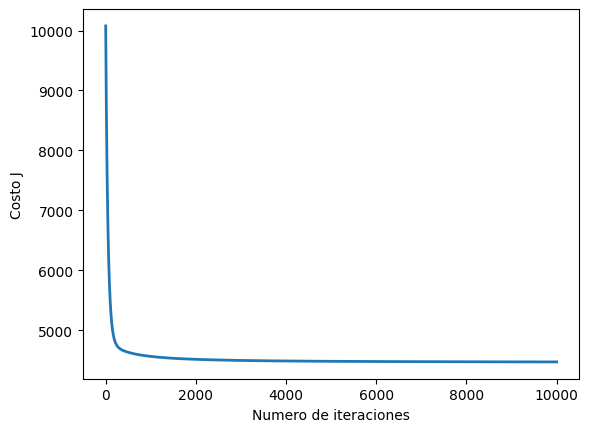

theta calculado por el descenso por el gradiente: [ 9.83877215e+01  1.74698359e+01 -8.07991273e+00  5.47850575e+01
 -2.73372661e+01 -4.59478011e+01  5.40128562e+01  1.59558408e+01
 -9.63938381e+00 -2.44757329e+00 -3.11925462e+00  1.59779884e+00
  2.96883528e+01  5.43505336e+00  4.44469480e+00 -7.16413981e+00
  1.56084921e+01 -2.35281773e+01 -3.04745515e+01 -4.65070161e+00
 -1.87067004e+01  1.26391962e+00 -7.68197479e-01  4.40072829e+00
  1.78021005e+00  3.80547834e-01 -5.30024078e-02 -5.33657173e-02]


In [53]:
# Elegir algun valor para alpha (probar varias alternativas)
alpha = 0.01 # Incrementado alpha para un aprendizaje mas efectivo  # Prueba con 0.1, 0.03, 0.01
num_iters = 10000

# inicializa theta y ejecuta el descenso por el gradiente
theta = np.zeros(X.shape[1]) # theta debe tener el mismo numero de elementos que columnas en X
theta, J_history = gradientDescentMulti(X, y, theta, alpha, num_iters)

# Grafica la convergencia del costo
pyplot.plot(np.arange(len(J_history)), J_history, lw=2)
pyplot.xlabel('Numero de iteraciones')
pyplot.ylabel('Costo J')
pyplot.show() # Asegura que la grafica se muestre

# Muestra los resultados del descenso por el gradiente
print('theta calculado por el descenso por el gradiente: {:s}'.format(str(theta)))
print('Costo calculado con theta calculado por el descenso por el gradiente: {:.2f}'.format(computeCostMulti(X, y, theta)))

In [54]:
# 1. Definir un ejemplo de prueba con los valores de las 27 características de tu dataset
# Las características corresponden a: [lights, T1, RH_1, T2, RH_2, ..., rv1, rv2]
X_array = np.array([
    30,      # lights
    19.89,   # T1
    47.59,   # RH_1
    19.20,   # T2
    44.79,   # RH_2
    19.79,   # T3
    44.73,   # RH_3
    19.00,   # T4
    45.56,   # RH_4
    17.16,   # T5
    55.20,   # RH_5
    7.02,    # T6
    84.25,   # RH_6
    17.20,   # T7
    41.62,   # RH_7
    18.20,   # T8
    48.90,   # RH_8
    17.03,   # T9
    45.53,   # RH_9
    6.60,    # T_out
    733.5,   # Press_mm_hg
    92.0,    # RH_out
    7.00,    # Windspeed
    63.00,   # Visibility
    5.3,     # Tdewpoint
    13.27,   # rv1
    13.27    # rv2
])

# 2. Normalizar las 27 características utilizando 'mu' y 'sigma' del entrenamiento
X_array_norm = (X_array - mu) / sigma

In [55]:
# 3. Añadir el término de intersección x0 = 1 al inicio del arreglo
X_array_ready = np.insert(X_array_norm, 0, 1)

# 4. Calcular la predicción mediante el producto punto entre X y theta
prediccion_appliances = np.dot(X_array_ready, theta)

print(f'Consumo estimado de electrodomésticos (Appliances): {prediccion_appliances:.2f} Wh')

Consumo estimado de electrodomésticos (Appliances): 169.52 Wh


<a id="section7"></a>
### 2.3 Ecuacion de la Normal

Una alternativa analítica para resolver el problema de la regresión lineal es mediante la solución cerrada conocida como la Ecuación de la Normal:

$$ \theta = \left( X^T X\right)^{-1} X^T\vec{y}$$

Utilizar esta fórmula matemática ofrece la ventaja de que no requiere escalar ni normalizar ninguna de las 27 características. Además, se obtiene una solución exacta en un solo paso algebraico, eliminando la necesidad de iteraciones, ajuste de la tasa de aprendizaje ($\alpha$) o bucles de convergencia como en el descenso por el gradiente.

Para implementar este método, primero reimportamos los datos limpios para asegurar que las variables explicativas no mantengan las modificaciones hechas por featureNormalize. Dado que no es necesario el escalado de características, procedemos únicamente a concatenar la columna de unos ($x_0 = 1$) a la matriz $X$ para incluir el término de intersección o sesgo ($\theta_0$).

In [56]:
# Cargar datos
# 1. Cargar el dataset con Pandas desde la ruta de Google Drive
data = '/content/gdrive/MyDrive/InteligenciaArtificial/energydata_complete - copia.csv'
df = pd.read_csv(data, sep=',')

# 2. Separar características (X) y variable objetivo (y)
X = df.iloc[:, 2:].values  # 27 características (lights hasta rv2)
y = df.iloc[:, 1].values   # Variable objetivo (Appliances)
m = y.size

print(f'Número de muestras (m): {m}')
print(f'Número de características (n): {X.shape[1]}')

# 3. Añadir la columna de unos (x0 = 1) para el término de intersección
# NOTA: En la Ecuación de la Normal NO se aplica featureNormalize(X)
X = np.concatenate([np.ones((m, 1)), X], axis=1)

Número de muestras (m): 20035
Número de características (n): 27


In [57]:
def normalEqn(X, y):

    theta = np.zeros(X.shape[1])

    # Se recomienda usar np.linalg.pinv (pseudoinversa) en lugar de inv
    # para evitar errores de matriz singular si hay columnas colineales.
    theta = np.dot(np.dot(np.linalg.pinv(np.dot(X.T, X)), X.T), y)

    return theta

In [58]:
# 1. Calcula los parámetros con la ecuación de la normal
theta = normalEqn(X, y)

# 2. Muestra los resultados obtenidos a partir de la aplicación de la ecuación de la normal
print('Theta calculado a partir de la ecuación de la normal:')
print(theta)

# 3. Estimar el consumo de energía de electrodomésticos (Appliances)
# Se pasa un vector de prueba con 27 características (valores en su escala original, SIN normalizar)
X_array = np.array([
    30,      # lights
    19.89,   # T1
    47.59,   # RH_1
    19.20,   # T2
    44.79,   # RH_2
    19.79,   # T3
    44.73,   # RH_3
    19.00,   # T4
    45.56,   # RH_4
    17.16,   # T5
    55.20,   # RH_5
    7.02,    # T6
    84.25,   # RH_6
    17.20,   # T7
    41.62,   # RH_7
    18.20,   # T8
    48.90,   # RH_8
    17.03,   # T9
    45.53,   # RH_9
    6.60,    # T_out
    733.5,   # Press_mm_hg
    92.0,    # RH_out
    7.00,    # Windspeed
    63.00,   # Visibility
    5.3,     # Tdewpoint
    13.27,   # rv1
    13.27    # rv2
])

# Se añade x0 = 1 al inicio del arreglo para alinearlo con theta_0
X_array_ready = np.insert(X_array, 0, 1)

# Cálculo del valor estimado mediante el producto punto
consumo_estimado = np.dot(X_array_ready, theta)

print(f'\nConsumo estimado de electrodomésticos (usando la ecuación de la normal): {consumo_estimado:.2f} Wh')

Theta calculado a partir de la ecuación de la normal:
[ 2.47290094e+01  2.15352170e+00 -6.32919388e-01  1.49293274e+01
 -1.75617590e+01 -1.34757240e+01  2.60749635e+01  5.18306879e+00
 -4.24837446e+00 -2.84288227e-01 -6.42060253e-01  1.65024740e-01
  6.67745861e+00  2.58175338e-01  2.37604338e+00 -1.43639929e+00
  7.72697789e+00 -4.40549603e+00 -1.52099187e+01 -1.02357853e+00
 -9.88717828e+00  1.64185555e-01 -1.11792445e+00  1.52358669e+00
  1.60974517e-01  5.19795162e+00 -3.70803427e-03 -3.29299918e-03]

Consumo estimado de electrodomésticos (usando la ecuación de la normal): 168.63 Wh
